# Create COGs From A Curvilinear NetCDF

In [2]:
from pathlib import Path


def find_repo_root(start: Path = Path.cwd()) -> Path:
    """Find the repository root when the kernel starts in a subfolder."""
    start = start.resolve()
    for path in (start, *start.parents):
        if (path / ".git").exists() or (path / "downloaded_data").exists():
            return path
    return start


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "downloaded_data"
DATA_DIR.mkdir(exist_ok=True)

import shutil
import subprocess

import matplotlib.pyplot as plt
import numpy as np
import rasterio
import rioxarray
import xarray as xr
from pyproj import CRS, Transformer
from scipy.spatial import cKDTree

NC_FILE = DATA_DIR / "SM_TEST_MIR_ITUDP4_20130101T000000_20141231T000000_200_001_0.nc"
TARGET_CRS = "EPSG:3031"
TARGET_RESOLUTION_M = 1000
DEPTHS_TO_CONVERT_M = [0, 500, 1000, 1500, 2000, 3000]
NODATA_VALUE = -9999.0

## Open The Source Dataset And Select Depths

Depth requests are snapped to the nearest available source depth so the output filenames match actual data values.


In [3]:
ds = xr.open_dataset(NC_FILE, decode_coords="all")
ds

<xarray.Dataset> Size: 17MB
Dimensions:      (x: 200, y: 224, depth: 91)
Coordinates:
  * depth        (depth) int16 182B 0 50 100 150 200 ... 4350 4400 4450 4500
Dimensions without coordinates: x, y
Data variables:
    latitude     (x, y) float64 358kB ...
    longitude    (x, y) float64 358kB ...
    Tice         (x, y, depth) float32 16MB ...
    QualityFlag  (x, y) float32 179kB ...
Attributes: (12/21)
    product:               Internal ice sheet temperature
    product_version:       2.0
    institution:           IFAC-CNR, IGE
    description:           developed from SMOS L3 (CATDS)
    source:                IFAC L4Tice processor
    project:               ESA CryoSMOS project (contract n.4000112262/14/I-NB)
    ...                    ...
    geospatial_lat_max:    0
    geospatial_lon_min:    -180
    geospatial_lon_max:    180
    spatial_resolution:    25 km
    srid:                  EPSG:6932
    creation_date:         2019-09-20T15:14:23

In [4]:
available_depths = ds["depth"].values
depth_indices = [int(np.argmin(np.abs(available_depths - depth))) for depth in DEPTHS_TO_CONVERT_M]
depth_indices = list(dict.fromkeys(depth_indices))
selected_depths = available_depths[depth_indices]
print("Selected depths:", selected_depths)


Selected depths: [   0  500 1000 1500 2000 3000]


## Build The EPSG:3031 Target Grid

The target grid is defined from the projected source footprint. Coordinates are cell centres, and `y` is descending so raster outputs have a conventional north-up transform.


In [5]:
lat = ds["latitude"].values
lon = ds["longitude"].values
lon = ((lon + 180) % 360) - 180

transformer = Transformer.from_crs("EPSG:4326", TARGET_CRS, always_xy=True)
source_x, source_y = transformer.transform(lon, lat)

geo_mask = np.isfinite(source_x) & np.isfinite(source_y)
source_points = np.column_stack([source_x[geo_mask], source_y[geo_mask]])

xmin = np.floor(np.nanmin(source_x) / TARGET_RESOLUTION_M) * TARGET_RESOLUTION_M
xmax = np.ceil(np.nanmax(source_x) / TARGET_RESOLUTION_M) * TARGET_RESOLUTION_M
ymin = np.floor(np.nanmin(source_y) / TARGET_RESOLUTION_M) * TARGET_RESOLUTION_M
ymax = np.ceil(np.nanmax(source_y) / TARGET_RESOLUTION_M) * TARGET_RESOLUTION_M

x_grid = np.arange(xmin + TARGET_RESOLUTION_M / 2, xmax, TARGET_RESOLUTION_M)
y_grid = np.arange(ymax - TARGET_RESOLUTION_M / 2, ymin, -TARGET_RESOLUTION_M)
target_xx, target_yy = np.meshgrid(x_grid, y_grid)
target_points = np.column_stack([target_xx.ravel(), target_yy.ravel()])

print(f"Target grid: {len(x_grid)} columns x {len(y_grid)} rows at {TARGET_RESOLUTION_M} m")


Target grid: 5672 columns x 5062 rows at 1000 m


## Reproject Values And Write One COG Per Depth

The KDTree lookup is computed once and reused for every depth slice. Missing source cells are written using a numeric nodata value because many GeoTIFF readers do not treat NaN consistently.


In [6]:
tree = cKDTree(source_points)
_, nearest_source_indices = tree.query(target_points, k=1)
nearest_source_indices = nearest_source_indices.reshape(target_xx.shape)

In [7]:


written_files = []
for depth_index, depth_value in zip(depth_indices, selected_depths):
    source_values = ds["Tice"].isel(depth=depth_index).values
    source_values = source_values[geo_mask]
    projected = source_values[nearest_source_indices].astype("float32")
    projected = np.where(np.isfinite(projected), projected, NODATA_VALUE).astype("float32")

    da = xr.DataArray(
        projected,
        dims=("y", "x"),
        coords={"y": y_grid, "x": x_grid},
        name="Tice",
        attrs={
            "long_name": "Ice sheet temperature",
            "units": ds["Tice"].attrs.get("units", "K"),
            "source_depth_m": float(depth_value),
            "reprojection_method": "nearest_source_point_after_projection",
        },
    )
    da = da.rio.write_crs(TARGET_CRS).rio.write_nodata(NODATA_VALUE)

    output_file = DATA_DIR / f"Tice_EPSG3031_depth_{int(round(float(depth_value)))}m.tif"
    da.rio.to_raster(
        output_file,
        driver="COG",
        compress="DEFLATE",
        blocksize=512,
        overview_resampling="nearest",
        BIGTIFF="IF_SAFER",
    )
    written_files.append(output_file)
    print(f"Wrote {output_file.name}")


Wrote Tice_EPSG3031_depth_0m.tif
Wrote Tice_EPSG3031_depth_500m.tif
Wrote Tice_EPSG3031_depth_1000m.tif
Wrote Tice_EPSG3031_depth_1500m.tif
Wrote Tice_EPSG3031_depth_2000m.tif
Wrote Tice_EPSG3031_depth_3000m.tif


## Validate And Inspect One Output


In [9]:
def validate_cog(path: Path) -> None:
    if shutil.which("rio") is None:
        print("rio CLI is not installed; skipping rio cogeo validation.")
        return
    result = subprocess.run(
        ["rio", "cogeo", "validate", str(path)],
        text=True,
        capture_output=True,
        check=False,
    )
    print(result.stdout or result.stderr)
    if result.returncode != 0:
        raise RuntimeError(f"COG validation failed for {path}")


for output_file in written_files:
    validate_cog(output_file)

/home/krasen/hackathon-repo/downloaded_data/Tice_EPSG3031_depth_0m.tif is a valid cloud optimized GeoTIFF

/home/krasen/hackathon-repo/downloaded_data/Tice_EPSG3031_depth_500m.tif is a valid cloud optimized GeoTIFF

/home/krasen/hackathon-repo/downloaded_data/Tice_EPSG3031_depth_1000m.tif is a valid cloud optimized GeoTIFF

/home/krasen/hackathon-repo/downloaded_data/Tice_EPSG3031_depth_1500m.tif is a valid cloud optimized GeoTIFF

/home/krasen/hackathon-repo/downloaded_data/Tice_EPSG3031_depth_2000m.tif is a valid cloud optimized GeoTIFF

/home/krasen/hackathon-repo/downloaded_data/Tice_EPSG3031_depth_3000m.tif is a valid cloud optimized GeoTIFF



Total overview levels found: 4


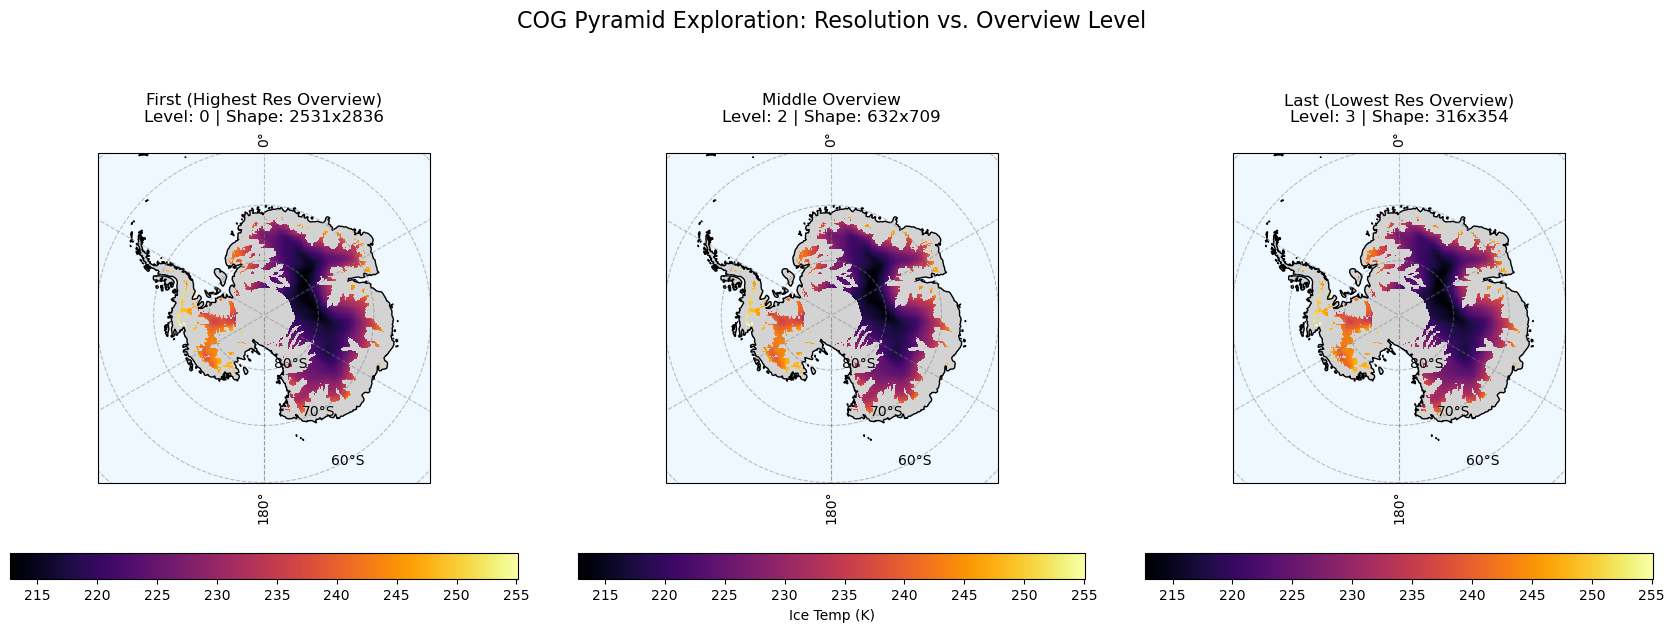

In [13]:
import rioxarray
import rasterio
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Define the path to your saved COG
cog_path = written_files[0]

# 2. Determine available overview levels dynamically using rasterio
with rasterio.open(cog_path) as src:
    # Get the list of downsampling factors (overviews) built into band 1
    overviews = src.overviews(1)
    num_overviews = len(overviews)

print(f"Total overview levels found: {num_overviews}")

# 3. Calculate First, Middle, and Last indices
# rioxarray uses 0-based indexing for overviews
first_level = 0
middle_level = num_overviews // 2
last_level = num_overviews - 1

levels_to_plot = [
    ("First (Highest Res Overview)", first_level),
    ("Middle Overview", middle_level),
    ("Last (Lowest Res Overview)", last_level)
]

# 4. Set up a 1x3 matplotlib figure with Cartopy projections
proj = ccrs.SouthPolarStereo()
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': proj})

# 5. Loop through our chosen levels and axes
for ax, (title_label, level_idx) in zip(axes, levels_to_plot):
    
    # Load just this specific overview level into memory
    da_overview = rioxarray.open_rasterio(
        cog_path, 
        overview_level=level_idx, 
        masked=True
    ).sel(band=1)
    
    # Set up map extent and basemap features
    ax.set_extent([-180, 180, -90, -60], ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0)
    ax.add_feature(cfeature.OCEAN, facecolor='aliceblue', zorder=0)
    ax.coastlines(resolution='50m', color='black', linewidth=1, zorder=2)
    ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    
    # Plot the data onto the current axis
    da_overview.plot.pcolormesh(
        ax=ax,
        x='x',
        y='y',
        transform=proj,
        cmap='inferno',
        zorder=1, 
        cbar_kwargs={
            'orientation': 'horizontal',
            'shrink': 0.8,
            'label': 'Ice Temp (K)' if ax == axes[1] else '' # Only label middle colorbar to save space
        }
    )
    
    # Update the title with dynamic shape information
    shape_str = f"{da_overview.shape[0]}x{da_overview.shape[1]}"
    ax.set_title(f"{title_label}\nLevel: {level_idx} | Shape: {shape_str}", fontsize=12)

# 6. Add a main title and adjust layout
plt.suptitle("COG Pyramid Exploration: Resolution vs. Overview Level", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()